In [1]:
import skimage as skim
import sklearn 
import cv2
import numpy as np

import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

In [2]:
train_data_path = '../data/dataset_project_iapr2025/train/'
easy_path = train_data_path + 'L1000756.JPG'
hard_path = train_data_path + 'L1010032.JPG'

### Visualisation

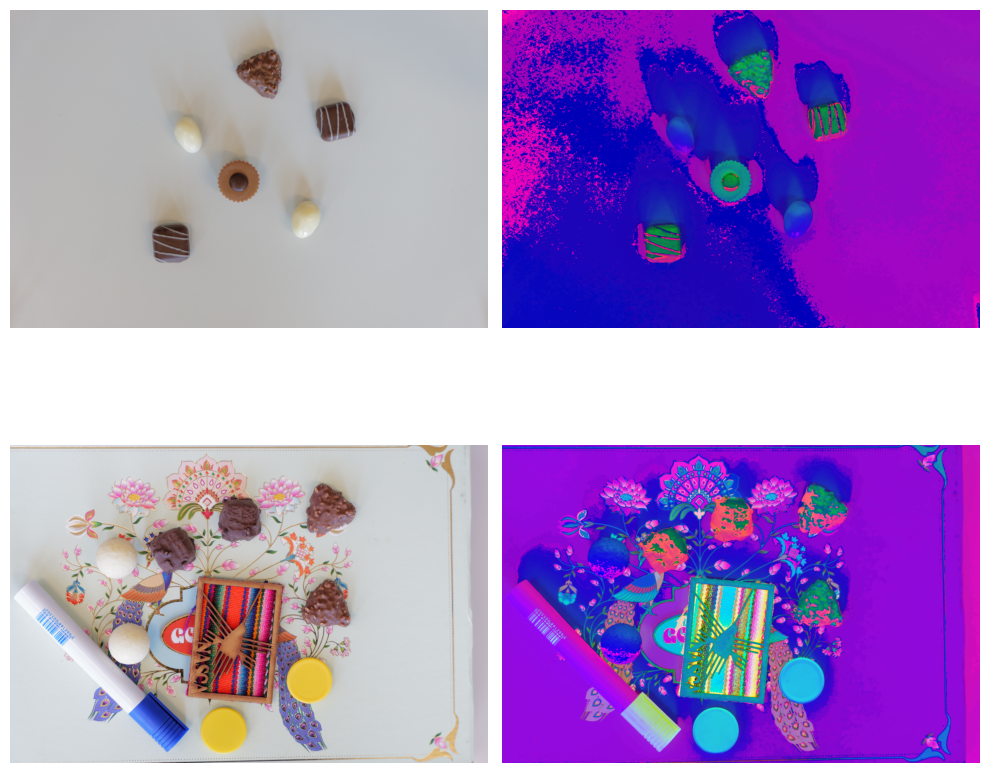

In [3]:


easy = np.array(Image.open(easy_path))
easy_hsv = skim.color.rgb2hsv(easy)

hard = np.array(Image.open(hard_path))
hard_hsv = skim.color.rgb2hsv(hard)

plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
plt.imshow(easy)
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(easy_hsv)
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(hard)
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(hard_hsv)
plt.axis('off')

plt.tight_layout()

plt.show()


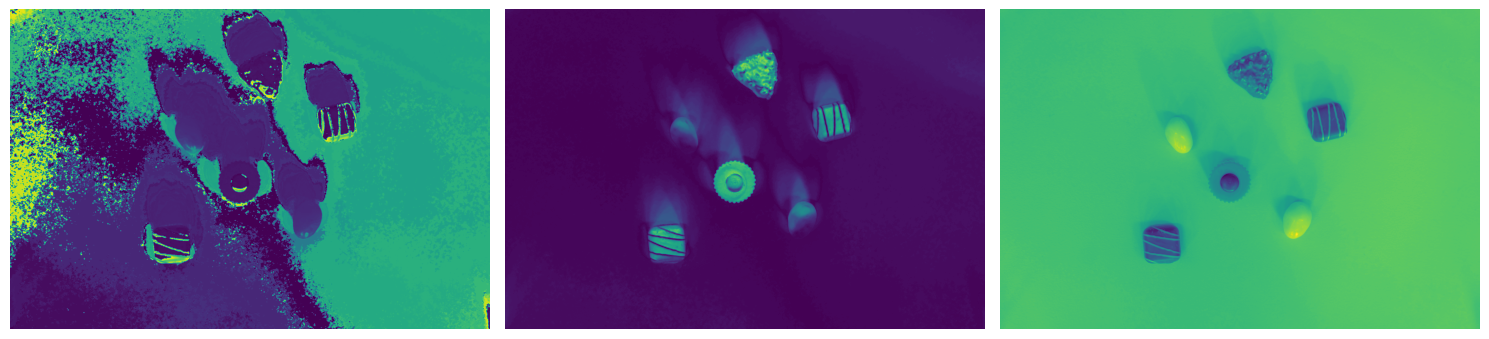

In [4]:

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(easy_hsv[:,:,0])
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(easy_hsv[:,:,1])
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(easy_hsv[:,:,2])
plt.axis('off')
plt.tight_layout()

plt.show()


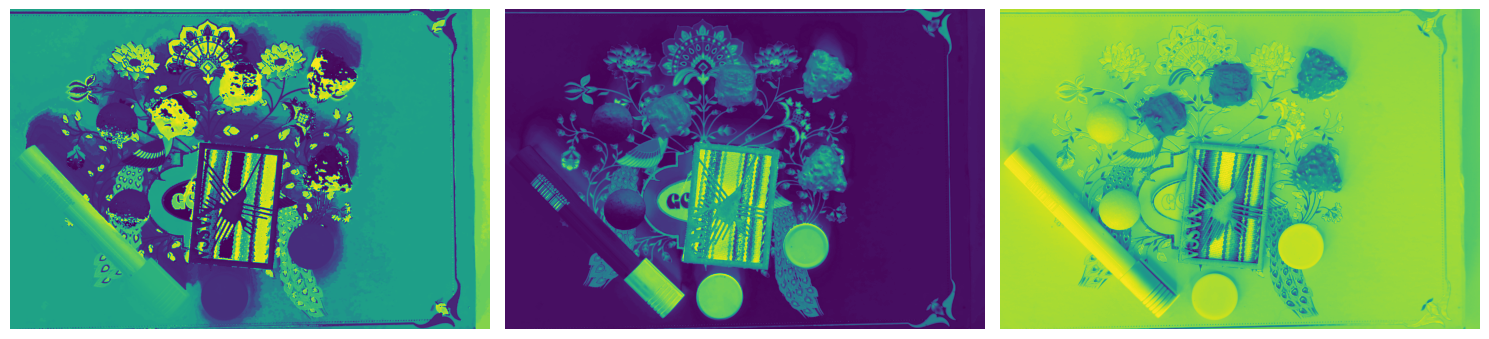

In [5]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(hard_hsv[:,:,0])
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(hard_hsv[:,:,1])
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(hard_hsv[:,:,2])
plt.axis('off')
plt.tight_layout()

plt.show()

**Histograms of HSV**

In [ ]:
img = np.array(Image.open(hard_path))
img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

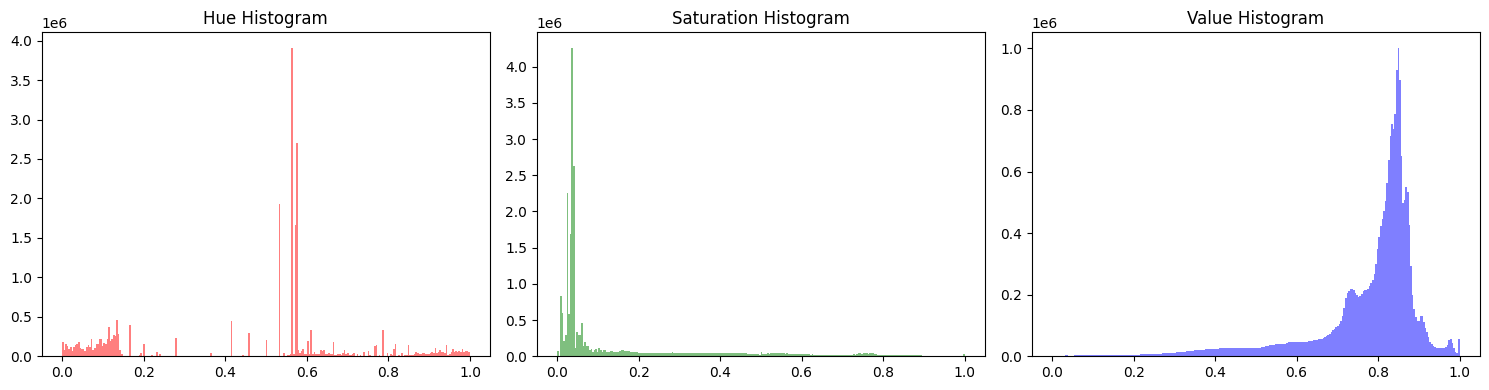

In [111]:
# visualize histograms
h = hsv[:,:,0]
s = hsv[:,:,1]
v = hsv[:,:,2]

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.hist(h.ravel(), bins=256, color='r', alpha=0.5) 
plt.title('Hue Histogram')
plt.subplot(1, 3, 2)
plt.hist(s.ravel(), bins=256, color='g', alpha=0.5)
plt.title('Saturation Histogram')
plt.subplot(1, 3, 3)
plt.hist(v.ravel(), bins=256, color='b', alpha=0.5)
plt.title('Value Histogram')
plt.tight_layout()
plt.show()

**Histograms after sampling**

24000000


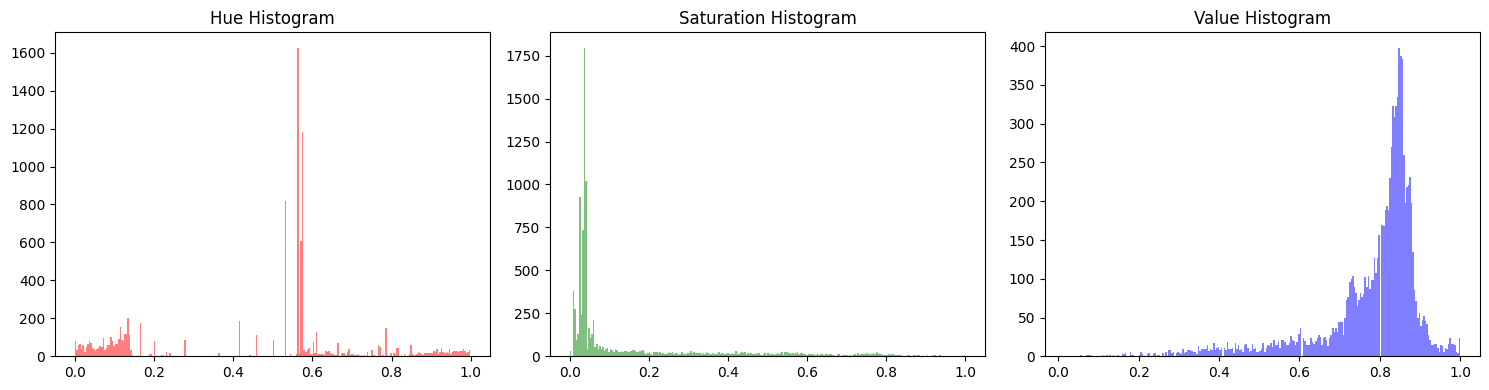

In [112]:
print(len(h.ravel()))

h = np.random.choice(h.ravel(), 10000)
s = np.random.choice(s.ravel(), 10000)
v = np.random.choice(v.ravel(), 10000)

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.hist(h, bins=256, color='r', alpha=0.5)
plt.title('Hue Histogram')
plt.subplot(1, 3, 2)
plt.hist(s, bins=256, color='g', alpha=0.5)
plt.title('Saturation Histogram')
plt.subplot(1, 3, 3)
plt.hist(v, bins=256, color='b', alpha=0.5)
plt.title('Value Histogram')
plt.tight_layout()
plt.show()



### GMM for segmentation
**Preprocessing: binning and bluring**

In [113]:
### median binning

def median_bin_rgb(image, block_size=(2, 2)):
    channels = []
    for i in range(3):  # R, G, B
        channel = skim.measure.block_reduce(image[:, :, i], block_size=block_size, func=np.median)
        channels.append(channel)
    return np.stack(channels, axis=-1).astype(np.uint8)


(400, 600, 3)


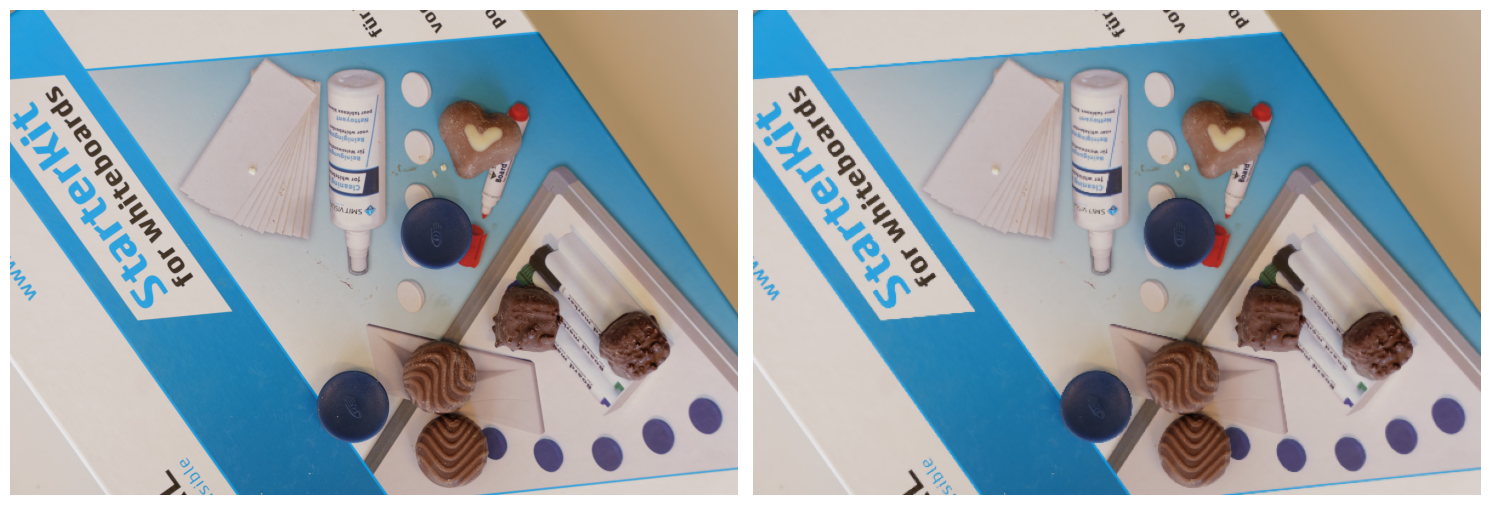

In [114]:
img = np.array(Image.open(train_data_path + 'L1000993.JPG'))
binned = median_bin_rgb(img, block_size=(10, 10))
binned = skim.filters.gaussian(binned, sigma=.4, channel_axis=2, preserve_range=True).astype(np.uint8)
print(binned.shape)

plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(binned)
plt.axis('off')
plt.tight_layout()
plt.show()

In [144]:
img_bgr = cv2.cvtColor(binned, cv2.COLOR_RGB2BGR)
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
#hsv = binned.copy()
#hsv = hsv[:,:, 1:3]
hsv = hsv.reshape(-1, 3)

empirical_mask = (hsv[:,0]>0) & (hsv[:,0]<100) & (hsv[:,1]>50) & (hsv[:,1]<200) & (hsv[:,2]>50) & (hsv[:,2]<180)


low_sat_mask = hsv[:, 1] < 0.2*255 #hue is very noisy when sat is low
hsv[low_sat_mask, 0] = 0


hsv_masked = hsv[empirical_mask]
components = range(1, 10)



sample_idx = np.random.choice(hsv_masked.shape[0], 10000, replace=False)
hsv_sample = hsv_masked[sample_idx, :]



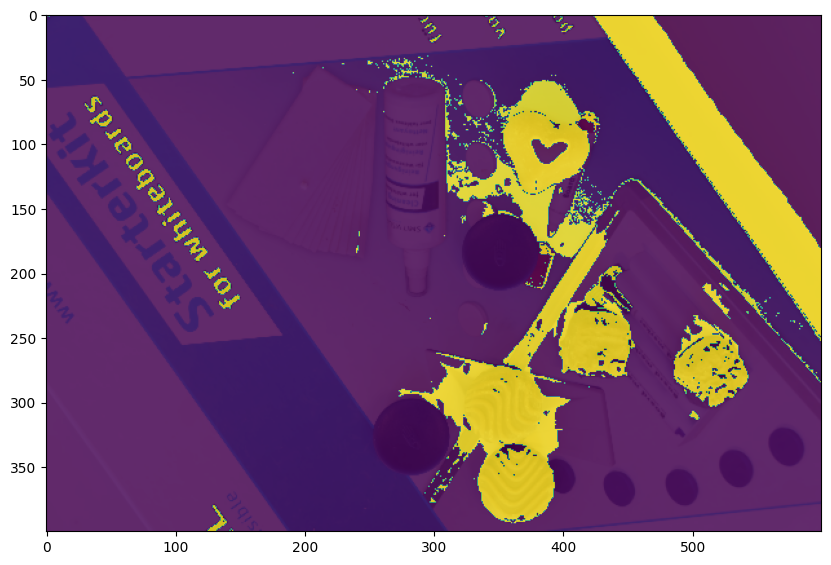

In [145]:
plt.figure(figsize=(10, 10))
plt.imshow(binned)
plt.imshow(empirical_mask.reshape(binned.shape[:2]), alpha=0.8)
plt.show()

100%|██████████| 9/9 [00:00<00:00,  9.16it/s]


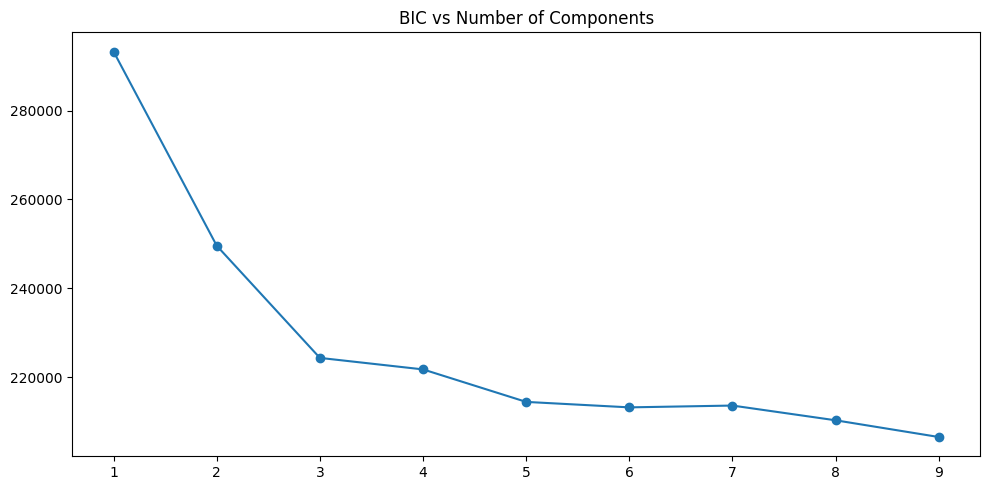

In [146]:
best_bic = np.inf
best_gmm = None
best_n_components = 0
bics = []

for c in tqdm(components):
    gmm = sklearn.mixture.GaussianMixture(n_components=c, covariance_type='full', reg_covar=1e-3)
    gmm.fit(hsv_sample)
    bic = gmm.bic(hsv_sample)
    bics.append(bic)
    if bic < best_bic:
        best_bic = bic
        best_gmm = gmm
        best_n_components = c

plt.figure(figsize=(10, 5))
plt.plot(components, bics, marker='o')
plt.title('BIC vs Number of Components')
plt.tight_layout()
plt.show()  


0 8


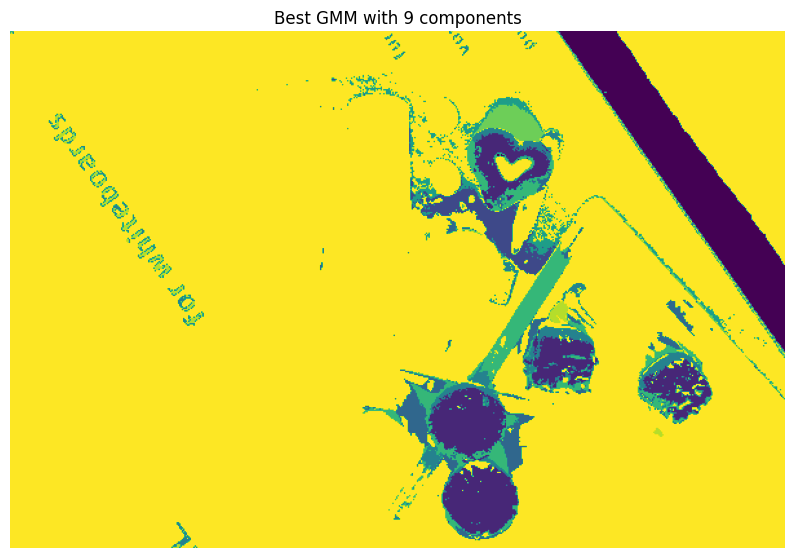

In [147]:
labels = best_gmm.predict(hsv)
print(np.min(labels), np.max(labels))
labels[~empirical_mask] = np.max(labels)+1
labels = labels.reshape(binned.shape[0], binned.shape[1])
plt.figure(figsize=(10, 10))
plt.imshow(labels)
plt.axis('off')
plt.title(f'Best GMM with {best_n_components} components')
plt.show()

In [141]:
print(best_gmm.means_)

[[  8.14866206 125.30959632 114.41614658]
 [ 10.87412419  88.41149179 114.05359237]
 [ 97.28624414 123.69580134 126.92240647]
 [ 16.63400668 104.37037273 171.1727786 ]
 [ 97.60843555  77.34947992 158.80624811]]


(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

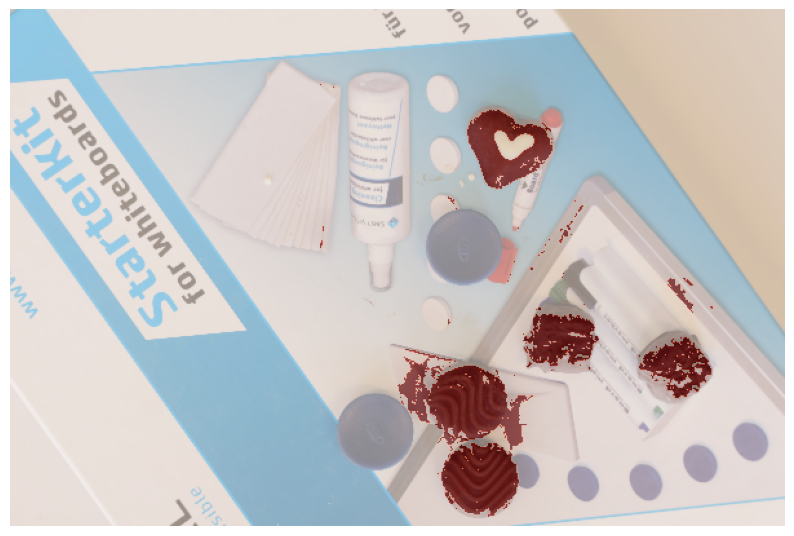

In [143]:
benchmark = [10, 125, 115]

distances = np.linalg.norm(best_gmm.means_ - benchmark, axis=1)
idx = np.argmin(distances)

binary = labels == idx
plt.figure(figsize=(10, 10))
plt.imshow(binned)
plt.imshow(binary, alpha=0.5, cmap='Reds')
plt.axis('off')


### Binary image processing


In [83]:
processed = skim.morphology.remove_small_holes(binary, area_threshold=200)
processed = skim.morphology.remove_small_objects(processed, min_size=50)
#processed = skim.morphology.binary_closing(processed, skim.morphology.disk(9))

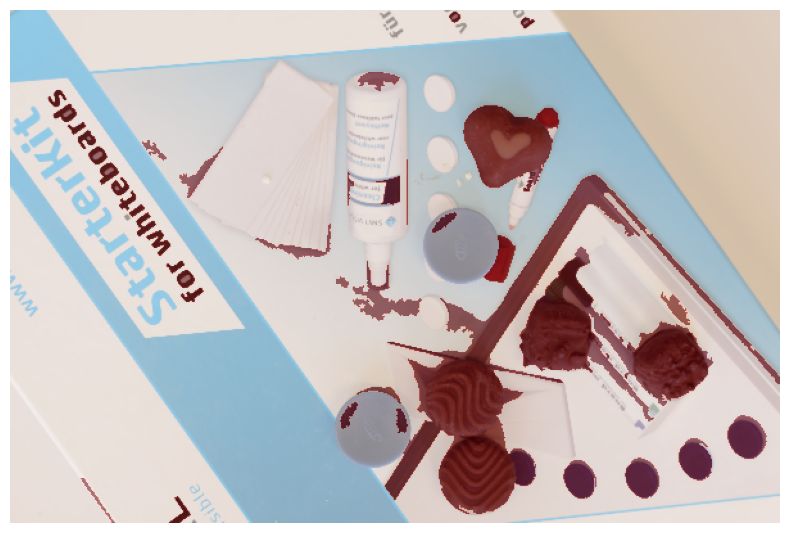

In [84]:
plt.figure(figsize=(8, 8))
plt.imshow(binned)
plt.imshow(processed, alpha=0.5, cmap='Reds')
plt.axis('off')
plt.tight_layout()
plt.show()